# Pipeline de Ejecución: Análisis y Pronóstico de Energía Solar

Este notebook integra secuencialmente los scripts de análisis y comparación de modelos para el proyecto de forecasting de energía solar.

**Orden de ejecución:**
1. Análisis de datos XM (`Analyze_xm.py`)
2. Análisis de correlación NASA-XM (`Analyze_NASA_xm_correlation.py`)
3. Estrategias de Validación SARIMAX (`Sarimax_strategies.py`)
4. Comparación Mensual Final (`FInal_Monthly_comparison.py`)
5. Comparación Diaria Final (`Final_comparison_daily_forecasting.py`)

In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Configuración de rutas base
PROJECT_ROOT = os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
EDA_DIR = os.path.join(PROJECT_ROOT, 'EDA')

os.makedirs(EDA_DIR, exist_ok=True)
print(f"Proyecto en: {PROJECT_ROOT}")

Proyecto en: d:\Software\Energy-forecasting


## Arquitecturas de Modelos
Definición de las clases y funciones para MLP, LSTM y XGBoost.

In [2]:
class SolarMLP(nn.Module):
    def __init__(self, input_size, hidden_size=256, dropout=0.3):
        super(SolarMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn3 = nn.BatchNorm1d(hidden_size // 2)
        self.relu3 = nn.ReLU()
        self.output = nn.Linear(hidden_size // 2, 1)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.drop1(self.relu1(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu2(self.bn2(self.fc2(x))))
        x = self.relu3(self.bn3(self.fc3(x)))
        return self.output(x)

class SolarLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2, output_window=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, 
                            num_layers=num_layers, dropout=dropout, batch_first=True, bidirectional=True)
        self.ln = nn.LayerNorm(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, output_window)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.ln(out[:, -1, :])
        return self.fc(out)

def train_xgboost(X_train, y_train):
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
    model.fit(X_train_flat, y_train)
    return model

def predict_xgboost_recursive(model, initial_context, steps, s_test, s_train, input_window, n_feat):
    current_context = initial_context.copy()
    preds = []
    for i in range(steps):
        inp = current_context[-input_window:].reshape(1, -1)
        p = model.predict(inp)[0]
        preds.append(p)
        future_idx = len(s_train) + i
        if future_idx < len(s_test):
            next_row = s_test[future_idx].copy()
            next_row[-1] = p
            current_context = np.vstack([current_context, next_row])
    return np.array(preds)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def add_cyclic_features(df):
    df['Fecha_Hora'] = pd.to_datetime(df['Fecha_Hora'])
    df['hour_sin'] = np.sin(2 * np.pi * df['Fecha_Hora'].dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['Fecha_Hora'].dt.hour / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['Fecha_Hora'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['Fecha_Hora'].dt.month / 12)
    return df

## Parte 1: Análisis Exploratorio XM
Procesamiento de `data_2019_2023_kwH_xm.csv` y generación de perfiles de generación.

--- Iniciando Análisis XM ---


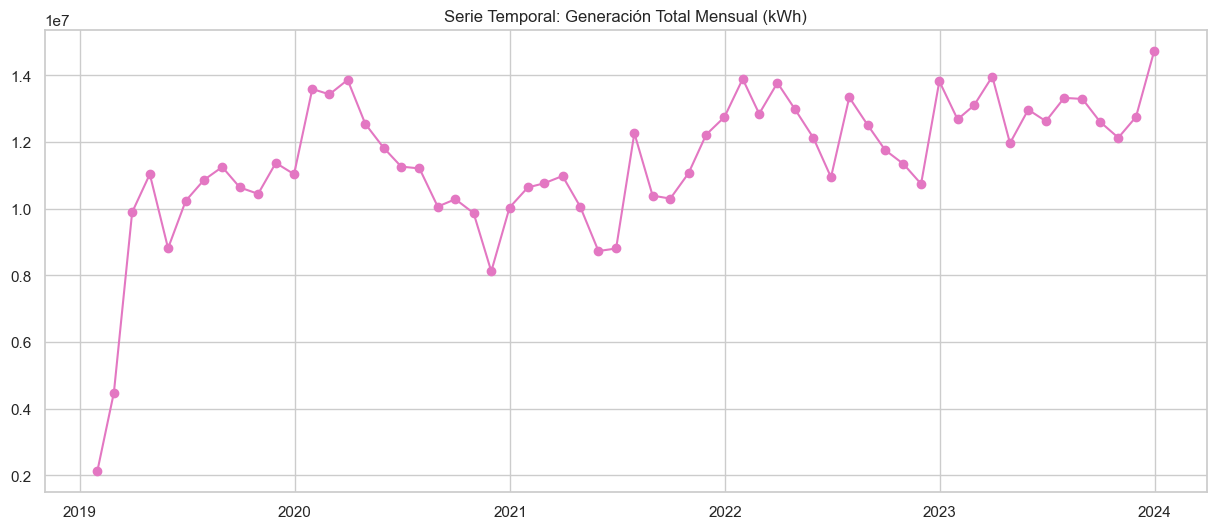

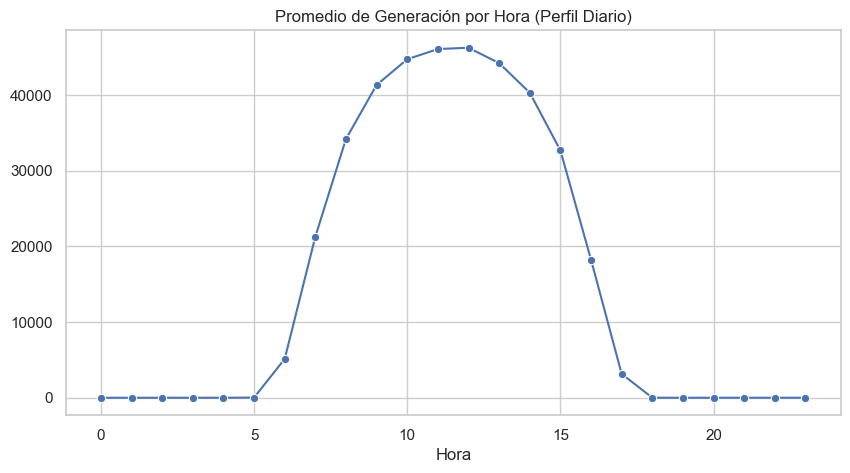

Archivo monthly-kwh.csv generado.


In [3]:
print("--- Iniciando Análisis XM ---")
file_path = os.path.join(DATA_DIR, 'data_2019_2023_kwH_xm.csv')
output_dir = os.path.join(EDA_DIR, 'XM')
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(file_path)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed')
hours = [str(i) for i in range(24)]

df_melted = df.melt(id_vars=['Fecha'], value_vars=hours, var_name='Hora', value_name='Generacion')
df_melted['Hora'] = df_melted['Hora'].astype(int)
df_melted['Timestamp'] = df_melted['Fecha'] + pd.to_timedelta(df_melted['Hora'], unit='h')
df_melted = df_melted.sort_values('Timestamp').reset_index(drop=True)
df_melted['Mes'] = df_melted['Timestamp'].dt.month

# 1. Serie temporal mensual
df_monthly_sum = df_melted.set_index('Timestamp')['Generacion'].resample('ME').sum().reset_index()
plt.figure(figsize=(15, 6))
plt.plot(df_monthly_sum['Timestamp'], df_monthly_sum['Generacion'], marker='o', color="#e377c2")
plt.title('Serie Temporal: Generación Total Mensual (kWh)')
plt.savefig(os.path.join(output_dir, 'serie_temporal_mensual_total.png'))
plt.show()

# 2. Promedio perfil diario
promedio_hora = df_melted.groupby('Hora')['Generacion'].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(x=promedio_hora.index, y=promedio_hora.values, marker="o")
plt.title('Promedio de Generación por Hora (Perfil Diario)')
plt.savefig(os.path.join(output_dir, 'promedio_generacion_hora.png'))
plt.show()

# Exportar monthly-kwh.csv para pasos posteriores
hourly_data_path = os.path.join(DATA_DIR, 'data-hourly.csv')
if os.path.exists(hourly_data_path):
    df_h = pd.read_csv(hourly_data_path)
    df_h['Fecha_Hora'] = pd.to_datetime(df_h['Fecha_Hora'])
    df_m = df_h.groupby(df_h['Fecha_Hora'].dt.to_period('M'))['kWh'].sum().reset_index()
    df_m.columns = ['Mes', 'Generacion_Total_kWh']
    df_m.to_csv(os.path.join(DATA_DIR, 'monthly-kwh.csv'), index=False)
    print("Archivo monthly-kwh.csv generado.")

## Parte 2: Correlación NASA vs XM
Análisis de la relación entre variables climáticas y generación.

--- Iniciando Análisis de Correlación NASA-XM ---


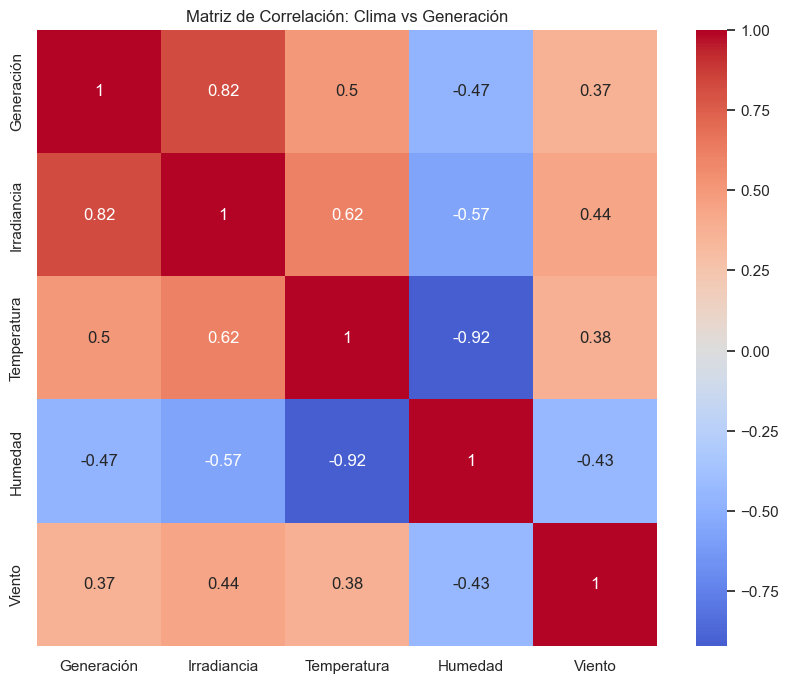

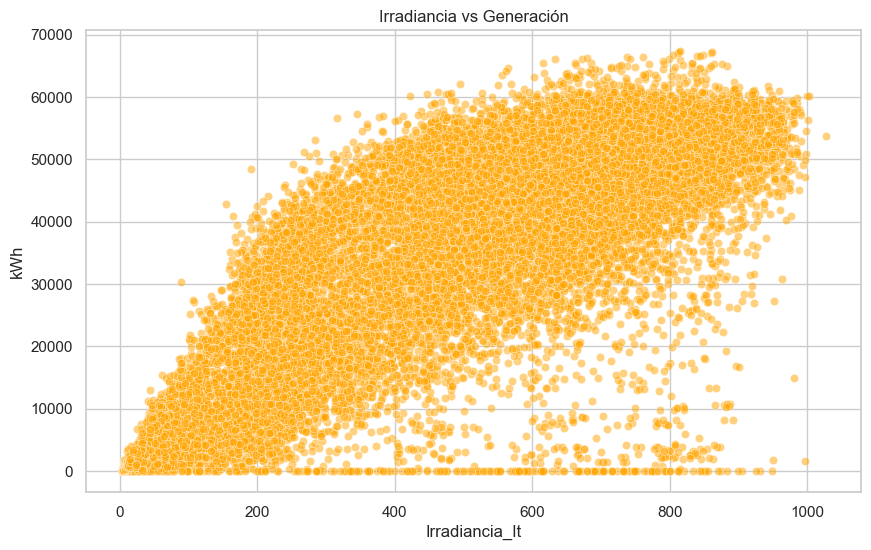

In [4]:
print("--- Iniciando Análisis de Correlación NASA-XM ---")
data_path = os.path.join(DATA_DIR, 'data-hourly.csv')
output_dir = os.path.join(EDA_DIR, 'NASA_xm_correlation')
os.makedirs(output_dir, exist_ok=True)

df_corr_raw = pd.read_csv(data_path)
cols = {'kWh': 'Generación', 'Irradiancia_It': 'Irradiancia', 'Temperatura_Tt': 'Temperatura', 'Humedad_Ht': 'Humedad', 'Viento_Wt': 'Viento'}
df_corr = df_corr_raw[list(cols.keys())].rename(columns=cols)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", center=0)
plt.title('Matriz de Correlación: Clima vs Generación')
plt.savefig(os.path.join(output_dir, '1_1_heatmap_correlacion.png'))
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_corr_raw, x='Irradiancia_It', y='kWh', alpha=0.5, color='orange')
plt.title('Irradiancia vs Generación')
plt.savefig(os.path.join(output_dir, 'scatter_irradiancia_vs_generacion.png'))
plt.show()

## Parte 3: Estrategias de Validación SARIMAX
Evaluación de Simple Split, Expanding Window y Sliding Window.

In [ ]:
print("--- Iniciando Estrategias SARIMAX ---")
# Configuración
DATA_PATH_STRAT = os.path.join(DATA_DIR, 'data-hourly.csv')
OUTPUT_DIR_STRAT = os.path.join(EDA_DIR, 'SARIMAX_training')
os.makedirs(OUTPUT_DIR_STRAT, exist_ok=True)

SEASONAL_PERIOD = 12
EXOG_COLS = ['Irradiancia_It', 'Temperatura_Tt', 'Humedad_Ht', 'Viento_Wt']
ORDER = (2, 0, 1)
SEASONAL_ORDER = (1, 1, 1, SEASONAL_PERIOD)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan

def compute_metrics_strat(y_true, y_pred, name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    return {'Estrategia': name, 'RMSE': rmse, 'MAE': mae_val, 'MAPE (%)': mape_val}

# Carga de datos
df_strat = pd.read_csv(DATA_PATH_STRAT)
df_strat['Fecha_Hora'] = pd.to_datetime(df_strat['Fecha_Hora'])
df_strat = df_strat.sort_values('Fecha_Hora').reset_index(drop=True)

# Split 70-20-10
n = len(df_strat)
n_train = int(n * 0.70)
n_val = int(n * 0.20)
train_strat = df_strat.iloc[:n_train]
val_strat = df_strat.iloc[n_train:n_train + n_val]

train_ts = train_strat['kWh']
exog_train = train_strat[EXOG_COLS]
val_ts = val_strat['kWh']
exog_val = val_strat[EXOG_COLS]

print(f"Entrenando SARIMAX base...")
base_model = SARIMAX(train_ts, exog=exog_train, order=ORDER, seasonal_order=SEASONAL_ORDER,
                    enforce_stationarity=False, enforce_invertibility=False)
base_result = base_model.fit(disp=False, maxiter=500)

results_metrics = []
predictions_dict = {}

# 1. Simple Split
print("Estrategia 1: División Simple...")
y_pred_simple = base_result.get_forecast(steps=len(val_ts), exog=exog_val).predicted_mean.values
results_metrics.append(compute_metrics_strat(val_ts.values, y_pred_simple, "1. División Simple"))
predictions_dict['Simple'] = y_pred_simple

# 2. Expanding Window
print("Estrategia 2: Ventana Expansiva...")
y_pred_expanding = []
current_res = base_result
step_size = SEASONAL_PERIOD
for i in range(0, len(val_ts), step_size):
    end_idx = min(i + step_size, len(val_ts))
    exog_future = exog_val.iloc[i:end_idx]
    fc = current_res.forecast(steps=len(exog_future), exog=exog_future)
    y_pred_expanding.extend(fc.values)
    current_res = current_res.extend(val_ts.iloc[i:end_idx], exog=exog_val.iloc[i:end_idx])
predictions_dict['Expansiva'] = np.array(y_pred_expanding)
results_metrics.append(compute_metrics_strat(val_ts.values, predictions_dict['Expansiva'], "2. Ventana Expansiva"))

# 3. Sliding Window
print("Estrategia 3: Ventana Deslizante...")
y_pred_sliding = []
full_ts = pd.concat([train_ts, val_ts])
full_exog = pd.concat([exog_train, exog_val])
for i in range(0, len(val_ts), step_size):
    end_idx = min(i + step_size, len(val_ts))
    global_train_end = n_train + i
    window_endog = full_ts.iloc[global_train_end - n_train : global_train_end]
    window_exog = full_exog.iloc[global_train_end - n_train : global_train_end]
    exog_future = full_exog.iloc[global_train_end : global_train_end + (end_idx - i)]
    sliding_res = base_result.apply(window_endog, exog=window_exog)
    fc = sliding_res.forecast(steps=len(exog_future), exog=exog_future)
    y_pred_sliding.extend(fc.values)
predictions_dict['Deslizante'] = np.array(y_pred_sliding)
results_metrics.append(compute_metrics_strat(val_ts.values, predictions_dict['Deslizante'], "3. Ventana Deslizante"))

# Resultados
df_metrics = pd.DataFrame(results_metrics)
print("\n--- Métricas Comparativas ---")
print(df_metrics.to_string(index=False))

# Gráfica
plt.figure(figsize=(15, 6))
last_month_idx = slice(-360, None)
val_dates = val_strat['Fecha_Hora']
plt.plot(val_dates.iloc[last_month_idx], val_ts.values[last_month_idx], label='Real', color='black', alpha=0.7)
plt.plot(val_dates.iloc[last_month_idx], predictions_dict['Simple'][last_month_idx], label='Simple Split')
plt.plot(val_dates.iloc[last_month_idx], predictions_dict['Expansiva'][last_month_idx], label='Ventana Expansiva')
plt.plot(val_dates.iloc[last_month_idx], predictions_dict['Deslizante'][last_month_idx], label='Ventana Deslizante')
plt.title('Comparación de Estrategias SARIMAX')
plt.legend()
plt.show()